<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Exercises_XP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercice 1 : Petit Quiz

1. **Différence clé entre ML traditionnel et Deep Learning** : Le Machine Learning traditionnel nécessite une extraction manuelle des caractéristiques (feature engineering), alors que le Deep Learning apprend automatiquement ces caractéristiques à partir des données brutes grâce aux réseaux de neurones profonds.
2. **Mimétisme du cerveau humain** : Les réseaux de neurones artificiels s'inspirent de la structure biologique du cerveau en utilisant des "neurones" interconnectés qui transmettent des signaux (poids) et s'activent lorsqu'un certain seuil est atteint.
3. **Performance sur de grands jeux de données** : Contrairement aux modèles traditionnels qui atteignent souvent un plateau de performance, le Deep Learning continue de s'améliorer à mesure que la quantité de données augmente car il possède une capacité de représentation beaucoup plus complexe.
4. **Défis du Deep Learning** : Les principaux défis sont le besoin massif de données et de puissance de calcul (GPU). On peut y remédier par le *Transfer Learning* (réutilisation de modèles pré-entraînés) ou l'augmentation de données.
5. **Feature Engineering** : C'est le processus de sélection et de transformation manuelle des variables pour aider le modèle. En Deep Learning, ce n'est pas nécessaire car les couches cachées extraient elles-mêmes les motifs pertinents (par exemple, détecter des bords puis des formes dans une image).
6. **Rôle des couches cachées** : Elles agissent comme des extracteurs de caractéristiques intermédiaires, permettant au modèle de comprendre des relations non linéaires et complexes entre les entrées et les sorties.
7. **Fonction d'activation** : Elle introduit de la non-linéarité dans le réseau, ce qui permet au modèle d'apprendre des motifs complexes au-delà d'une simple ligne droite.

*Exemple 1 (Défi)* : Pour entraîner un modèle de reconnaissance faciale sans avoir des millions d'images, on utilise le Transfer Learning avec un modèle déjà entraîné par Google.
*Exemple 2 (Couches cachées)* : Dans la reconnaissance de chiffres, les premières couches détectent des lignes, et les couches profondes assemblent ces lignes pour reconnaître un '8'.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [ ]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [14]:
# On s'assure que la fonction d'activation est définie localement si la cellule précédente a échoué
def step_activation(s, threshold=20.0):
    return 1 if s > threshold else 0

W_TEMP, W_RAIN, BIAS = 0.6, 0.4, 2.0

def weighted_sum(temperature_f: float, rain01: int) -> float:
    return (W_TEMP * temperature_f) + (W_RAIN * rain01) + BIAS

s1 = weighted_sum(70, 0)
s2 = weighted_sum(50, 1)

y1 = step_activation(s1)
y2 = step_activation(s2)

print(f"Cas 1: Somme={s1:.1f} -> {'Sortir' if y1==1 else 'Rester'}")
print(f"Cas 2: Somme={s2:.1f} -> {'Sortir' if y2==1 else 'Rester'}")

Cas 1: Somme=44.0 -> Sortir
Cas 2: Somme=32.4 -> Sortir


**Interprétation des résultats :**

Le perceptron a suggéré de **Sortir** (1) dans les deux cas car la somme pondérée a dépassé le seuil de 20.
- **Cas 1 (Somme = 44.0)** : La température élevée (70) multipliée par son poids (0.6) suffit largement à franchir le seuil, même sans pluie.
- **Cas 2 (Somme = 32.4)** : Bien que la température soit plus basse, l'ajout du biais (2.0) et du poids de la pluie permet de rester au-dessus de 20.

Le **Biais** joue ici un rôle de facilitateur : il donne un score de départ de 2.0 au système avant même de considérer la météo, décalant ainsi la limite de décision.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [ ]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [15]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# Re-chargement rapide des données si nécessaire pour éviter le NameError
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Encodage One-hot
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Dimensions après encodage :", y_train_oh.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensions après encodage : (60000, 10)


In [10]:
from tensorflow.keras import layers, models

# Architecture du réseau de neurones
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Conversion image 2D en vecteur 1D
    layers.Dense(128, activation='relu'), # Couche cachée
    layers.Dense(10, activation='softmax') # Couche de sortie (probabilités)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compilation avec les paramètres standards
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# Entraînement sur 5 époques
# On utilise verbose=1 pour voir la progression
print("Début de l'entraînement...")
model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

# Évaluation finale
loss, acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"\nPrécision finale sur le jeu de test : {acc:.4f}")

Début de l'entraînement...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9215 - loss: 0.2706 - val_accuracy: 0.9617 - val_loss: 0.1307
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9646 - loss: 0.1221 - val_accuracy: 0.9758 - val_loss: 0.0894
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9752 - loss: 0.0835 - val_accuracy: 0.9720 - val_loss: 0.0983
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9820 - loss: 0.0610 - val_accuracy: 0.9787 - val_loss: 0.0795
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0473 - val_accuracy: 0.9763 - val_loss: 0.0821

Précision finale sur le jeu de test : 0.9739


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [6]:
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# Calcul de z
z = x1*w1 + x2*w2 + b

# Application de ReLU : max(0, z)
y = max(0.0, z)

print({"z": z, "prediction_price": y})

{'z': 51002.1, 'prediction_price': 51002.1}


**Interprétation du prix immobilier :**

Le prix prédit est de **51 002.1**.

L'influence du **biais** (50 000) est ici prédominante : il représente le prix de base du terrain ou des frais fixes, peu importe la taille de la maison. La mise à l'échelle des entrées montre que chaque pied carré ajoute 0.5 unité au prix, tandis que chaque chambre ajoute 0.7 unité. L'activation **ReLU** n'a pas modifié le résultat ici car la valeur était positive, mais elle garantirait que le prix ne puisse jamais être négatif (en retournant 0) si les calculs aboutissaient à une valeur absurde en dessous de zéro.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [ ]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


**Explication du Gradient Descent :**

La descente de gradient réduit l'erreur en calculant la direction dans laquelle les poids doivent être modifiés pour minimiser la fonction de perte (Loss). C'est comme descendre une montagne dans le brouillard en suivant la pente la plus raide.

- Si on augmente le **learning rate** (ex: 0.5), le modèle fait des pas de géant : il peut apprendre plus vite mais risque de dépasser le minimum et de ne jamais converger.
- Si on utilise un **learning rate** trop petit (ex: 0.0001), la perte diminue très lentement, ce qui nécessite beaucoup plus de temps de calcul.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


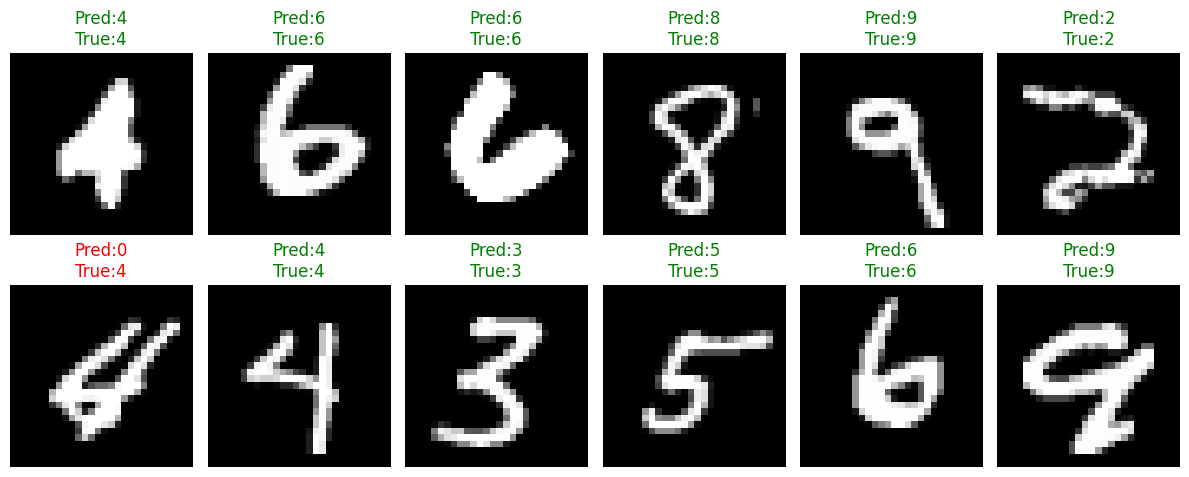

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Sélection de 12 images aléatoires du jeu de test
indices = np.random.choice(len(x_test), 12)
images = x_test[indices]
labels = y_test[indices]

# Prédictions du modèle
preds = np.argmax(model.predict(images), axis=1)

# Visualisation
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(2, 6, i+1)
    plt.imshow(images[i], cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"Pred:{preds[i]}\nTrue:{labels[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()